# Análisis Estadístico — Estación PSANL (Salinillas, N.L.)
**Comisión Nacional del Agua | Subdirección General Técnica**  
Datos hidrológicos diarios: 1941 – 2026

---
## Paso 0 — Limpieza y preparación del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#VERSION DE WINDOWS
df = pd.read_csv('..\\Datasets\\PSANL.csv', skiprows=7, parse_dates=['Fecha'])
df.head()

In [ ]:
# El archivo tiene 7 líneas de encabezado institucional antes de los datos VERSION DE MAC - si no es tu caso ignora esta celda
df = pd.read_csv('../Datasets/PSANL.csv', skiprows=7, parse_dates=['Fecha'])
df.head()

,Estacion,Fecha,Precipitacion(mm),ObraToma(m3/s),Vertedor(m3/s),Derrame(m3/s),VolumenAlm(Mm3),Evaporacion(mm)
0,PSANL,1941-01-01,0.0,NaN,NaN,NaN,NaN,NaN
1,PSANL,1941-01-02,0.0,NaN,NaN,NaN,NaN,NaN
2,PSANL,1941-01-03,0.0,NaN,NaN,NaN,NaN,NaN
3,PSANL,1941-01-04,0.0,NaN,NaN,NaN,NaN,NaN
4,PSANL,1941-01-05,0.0,NaN,NaN,NaN,NaN,NaN


In [11]:
# Forma del archivo
df.shape

(30502, 11)

In [3]:
# Renombramos columnas para mayor claridad
df.rename(columns={
    'Estacion'          : 'estacion',
    'Fecha'             : 'fecha',
    'Precipitacion(mm)' : 'precipitacion_mm',
    'ObraToma(m3/s)'    : 'obra_toma_m3s',
    'Vertedor(m3/s)'    : 'vertedor_m3s',
    'Derrame(m3/s)'     : 'derrame_m3s',
    'VolumenAlm(Mm3)'   : 'volumen_alm_mm3',
    'Evaporacion(mm)'   : 'evaporacion_mm'
}, inplace=True)
df.head()

,estacion,fecha,precipitacion_mm,obra_toma_m3s,vertedor_m3s,derrame_m3s,volumen_alm_mm3,evaporacion_mm
0,PSANL,1941-01-01,0.0,NaN,NaN,NaN,NaN,NaN
1,PSANL,1941-01-02,0.0,NaN,NaN,NaN,NaN,NaN
2,PSANL,1941-01-03,0.0,NaN,NaN,NaN,NaN,NaN
3,PSANL,1941-01-04,0.0,NaN,NaN,NaN,NaN,NaN
4,PSANL,1941-01-05,0.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# Columnas de apoyo temporal para el análisis por año y década
df['año']    = df['fecha'].dt.year
df['mes']    = df['fecha'].dt.month
df['decada'] = (df['año'] // 10) * 10
df.head()

,estacion,fecha,precipitacion_mm,obra_toma_m3s,vertedor_m3s,derrame_m3s,volumen_alm_mm3,evaporacion_mm,año,mes,decada
0,PSANL,1941-01-01,0.0,NaN,NaN,NaN,NaN,NaN,1941,1,1940
1,PSANL,1941-01-02,0.0,NaN,NaN,NaN,NaN,NaN,1941,1,1940
2,PSANL,1941-01-03,0.0,NaN,NaN,NaN,NaN,NaN,1941,1,1940
3,PSANL,1941-01-04,0.0,NaN,NaN,NaN,NaN,NaN,1941,1,1940
4,PSANL,1941-01-05,0.0,NaN,NaN,NaN,NaN,NaN,1941,1,1940


In [7]:
# eliminar duplicados
df.drop_duplicates(inplace=True)

In [8]:
# Columnas numéricas de interés
VARS_NUM = ['precipitacion_mm', 'obra_toma_m3s', 'vertedor_m3s',
            'derrame_m3s', 'volumen_alm_mm3', 'evaporacion_mm']

# Verificar nulos antes de rellenar
print('Nulos por columna:')
print(df[VARS_NUM].isnull().sum())

Nulos por columna:
precipitacion_mm        0
obra_toma_m3s       18712
vertedor_m3s        18712
derrame_m3s         18712
volumen_alm_mm3     18758
evaporacion_mm      18840
dtype: int64


In [9]:
# Rellenar valores nulos con la media de cada columna
for col in VARS_NUM:
    df[col] = df[col].fillna(df[col].mean())

print('Nulos después de rellenar:')
print(df[VARS_NUM].isnull().sum())

Nulos después de rellenar:
precipitacion_mm    0
obra_toma_m3s       0
vertedor_m3s        0
derrame_m3s         0
volumen_alm_mm3     0
evaporacion_mm      0
dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30502 entries, 0 to 30501
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   estacion          30502 non-null  object        
 1   fecha             30502 non-null  datetime64[ns]
 2   precipitacion_mm  30502 non-null  float64       
 3   obra_toma_m3s     30502 non-null  float64       
 4   vertedor_m3s      30502 non-null  float64       
 5   derrame_m3s       30502 non-null  float64       
 6   volumen_alm_mm3   30502 non-null  float64       
 7   evaporacion_mm    30502 non-null  float64       
 8   año               30502 non-null  int32         
 9   mes               30502 non-null  int32         
 10  decada            30502 non-null  int32         
dtypes: datetime64[ns](1), float64(6), int32(3), object(1)
memory usage: 2.2+ MB


---
## Paso 1 — Análisis estadístico descriptivo

In [13]:
# Media, mediana, desv. estándar, mín, máx y cuartiles
df[VARS_NUM].describe().round(3)

,precipitacion_mm,obra_toma_m3s,vertedor_m3s,derrame_m3s,volumen_alm_mm3,evaporacion_mm
count,30502.000,30502.000,30502.000,30502.0,30502.000,30502.000
mean,1.182,2.626,0.000,0.0,11.001,5.268
std,6.534,2.656,0.002,0.0,1.841,1.730
min,0.000,0.000,0.000,0.0,1.204,0.000
25%,0.000,0.500,0.000,0.0,11.001,5.268
50%,0.000,2.626,0.000,0.0,11.001,5.268
75%,0.000,2.626,0.000,0.0,11.001,5.268
max,160.000,34.000,0.400,0.0,17.940,22.500


In [14]:
# Moda, rango, varianza y asimetría (no incluidos en describe)
for col in VARS_NUM:
    serie = df[col]
    print(f'--- {col} ---')
    print(f'  Media:     {serie.mean():.4f}')
    print(f'  Mediana:   {serie.median():.4f}')
    print(f'  Moda:      {serie.mode()[0]:.4f}')
    print(f'  Mínimo:    {serie.min():.4f}')
    print(f'  Máximo:    {serie.max():.4f}')
    print(f'  Rango:     {serie.max() - serie.min():.4f}')
    print(f'  Varianza:  {serie.var():.4f}')
    print(f'  Desv. Std: {serie.std():.4f}')
    print(f'  Asimetría: {serie.skew():.4f}')
    print()

--- precipitacion_mm ---
  Media:     1.1824
  Mediana:   0.0000
  Moda:      0.0000
  Mínimo:    0.0000
  Máximo:    160.0000
  Rango:     160.0000
  Varianza:  42.6940
  Desv. Std: 6.5341
  Asimetría: 10.0745

--- obra_toma_m3s ---
  Media:     2.6263
  Mediana:   2.6263
  Moda:      2.6263
  Mínimo:    0.0000
  Máximo:    34.0000
  Rango:     34.0000
  Varianza:  7.0535
  Desv. Std: 2.6558
  Asimetría: 3.3145

--- vertedor_m3s ---
  Media:     0.0000
  Mediana:   0.0000
  Moda:      0.0000
  Mínimo:    0.0000
  Máximo:    0.4000
  Rango:     0.4000
  Varianza:  0.0000
  Desv. Std: 0.0023
  Asimetría: 174.6346

--- derrame_m3s ---
  Media:     0.0000
  Mediana:   0.0000
  Moda:      0.0000
  Mínimo:    0.0000
  Máximo:    0.0000
  Rango:     0.0000
  Varianza:  0.0000
  Desv. Std: 0.0000
  Asimetría: 0.0000

--- volumen_alm_mm3 ---
  Media:     11.0006
  Mediana:   11.0006
  Moda:      11.0006
  Mínimo:    1.2040
  Máximo:    17.9400
  Rango:     16.7360
  Varianza:  3.3899
  Desv. S

**Interpretación:**  
- La desviación estándar alta en `precipitacion_mm` indica alta variabilidad: la mayoría de días son secos pero los eventos de lluvia extrema disparan los valores.  
- Cuando la media > mediana (asimetría positiva) existe una cola hacia valores altos, típico en precipitación y caudal.  
- Los valores atípicos en datos hidrológicos corresponden a eventos reales (tormentas, sequías) y no se eliminan.
- Se puede decir con seguridad que este dataset es de calidad por lo que no hay muchos datos atipicos, los que hay son de situaciones extremas reales.
- Hay muchos valores en 0 (NO SON NULOS) y es posible que estos valores sean 0 porque no se conocen los valores exactos.
- Este dataset como se puede ver en la asimetria es una asimetria moderada hacia la izquierda.. Entre 0.5 y 1.0 (o -0.5 y -1.0): Asimetría moderada y se debe mas que nada al ser un dataset tan grande y con muchos 0 estos se identifican como outliers. pero eso no nescesariamente que los datos sean malos o inutilizables.

---
## Paso 2 — Histogramas

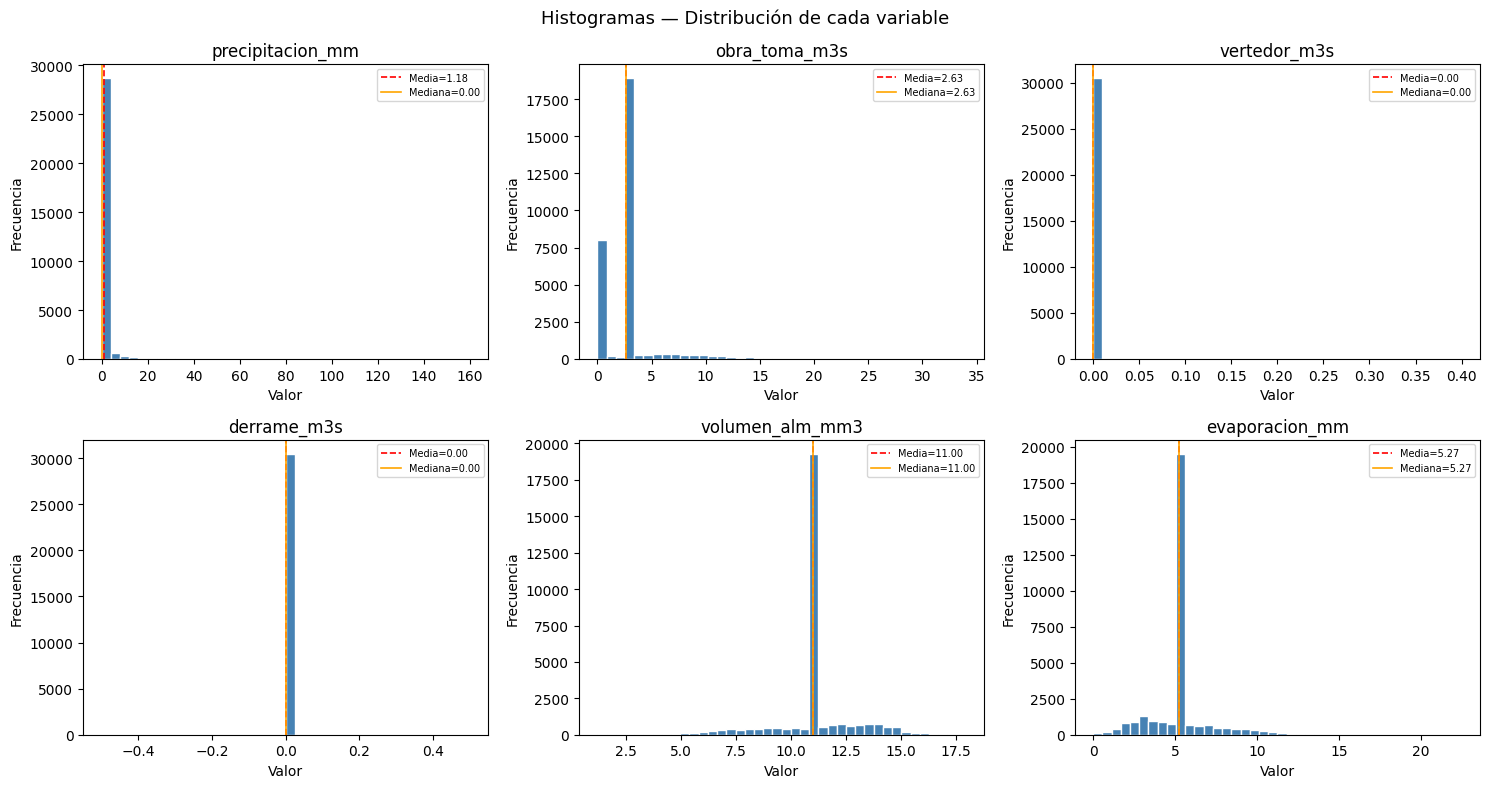

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(VARS_NUM):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Media={df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-',  linewidth=1.2, label=f'Mediana={df[col].median():.2f}')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=7)

plt.suptitle('Histogramas — Distribución de cada variable', fontsize=13)
plt.tight_layout()
plt.show()

# La mayoría de variables tienen sesgo positivo (cola hacia la derecha)
# La precipitación muestra que casi todos los días no llueve; hay pocos días con lluvia intensa
# El volumen de almacenamiento también tiene una distribución sesgada, con muchos días con bajo volumen y pocos días con volumen alto, lo cual es logico porque solo llueve en algunos días del año
# El volumen de lluvia también tiene una distribución sesgada, con muchos días con bajo volumen y pocos días con volumen alto, lo cual es logico porque solo llueve en algunos días del año
# El volumen de evaporación también tiene una distribución sesgada, con muchos días con bajo volumen y pocos días con volumen alto, lo cual es logico porque solo llueve en algunos días del año
# Vertedor por metro cubico por segundo tambien es logico solo los dias que llueve se vierte por eso esta tan allegado al 0
# como podemos ver volumen_alm_mm3, derrame_m3s, vertedor_m3s y evaporacion_mm tienen una distribución similar, lo cual es lógico porque están relacionados con la cantidad de agua que entra al sistema (precipitación) y cómo se maneja esa agua (almacenamiento, vertido, evaporación), lo podremos ver mejor en el siguiente análisis


---
## Paso 3 — Diagramas de densidad

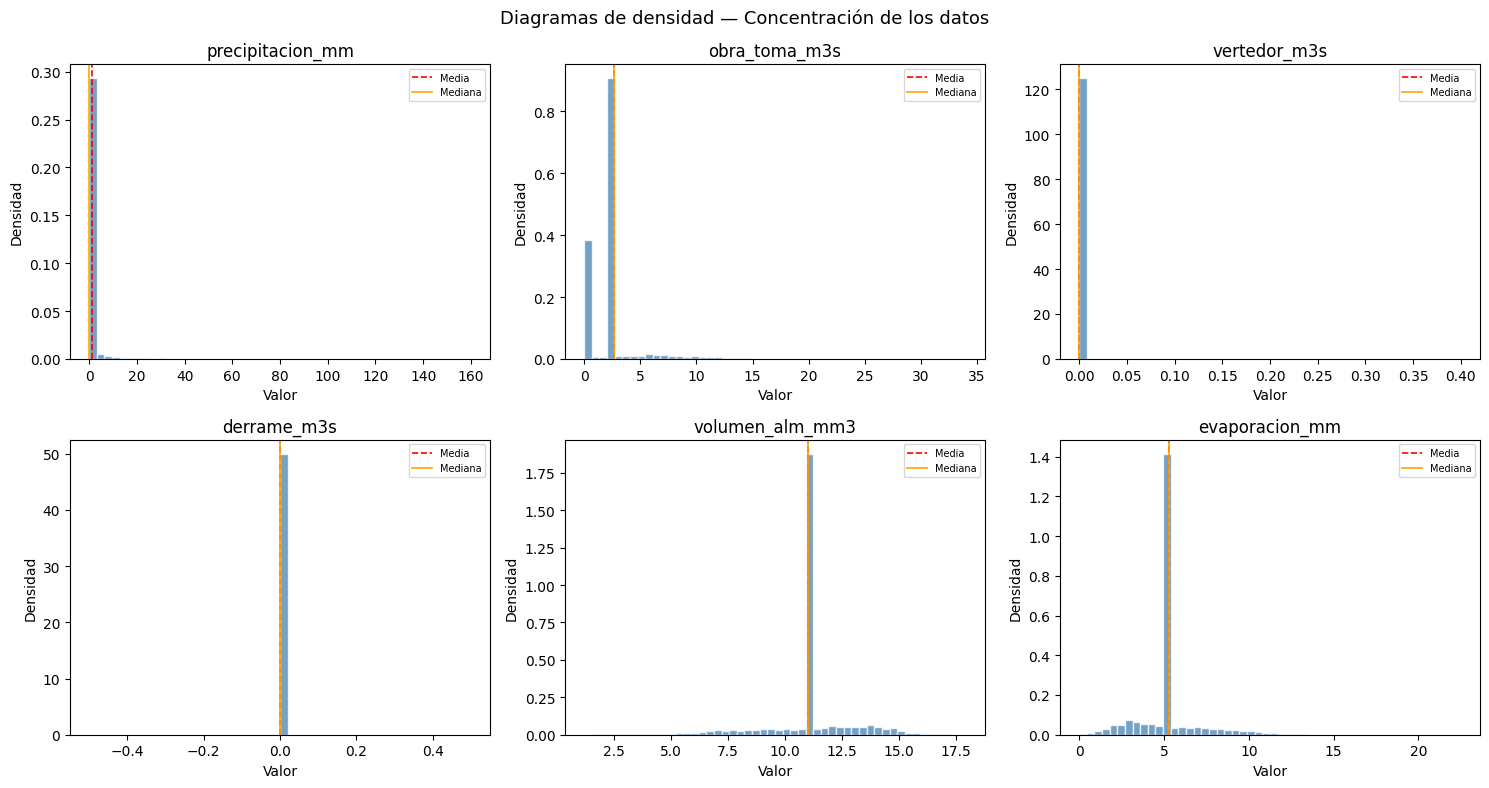

In [16]:
# density=True normaliza el histograma para mostrar densidad de probabilidad
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(VARS_NUM):
    axes[i].hist(df[col], bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.75)
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.2, label='Media')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-',  linewidth=1.2, label='Mediana')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=7)

plt.suptitle('Diagramas de densidad — Concentración de los datos', fontsize=13)
plt.tight_layout()
plt.show()

# El pico alto cerca de cero en precipitación confirma que la mayoría de registros son días sin lluvia
# El volumen almacenado y la evaporación muestran distribuciones más simétricas

---
## Paso 4 — Boxplots

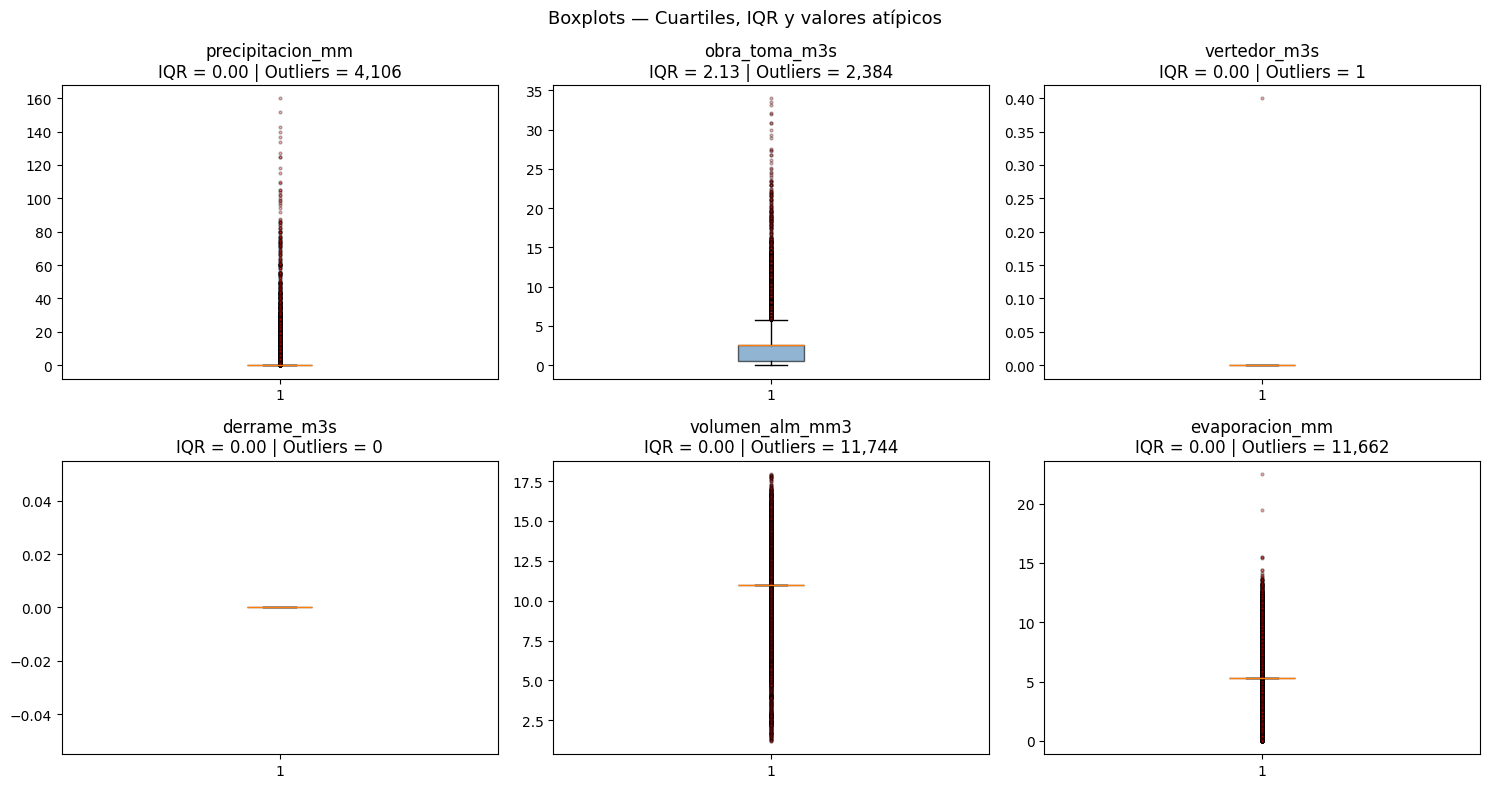

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(VARS_NUM):
    axes[i].boxplot(df[col],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, markerfacecolor='red'))
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    axes[i].set_title(f'{col}\nIQR = {IQR:.2f} | Outliers = {n_out:,}')

plt.suptitle('Boxplots — Cuartiles, IQR y valores atípicos', fontsize=13)
plt.tight_layout()
plt.show()

# Los puntos rojos son valores atípicos; en hidrología corresponden a eventos extremos reales
# El IQR mide la dispersión del 50% central de los datos

# precipitacion_mm: IQR = 0, significa que el 50% central de los días tiene 0mm de lluvia
# Los 4,106 outliers son los días donde sí llovió — confirma que la lluvia es un evento poco frecuente pero intenso

# obra_toma_m3s: es la única variable con un IQR visible (2.13), lo que indica que sí hay variabilidad real en el caudal extraído
# Sus outliers corresponden a días de alta demanda o grandes avenidas

# vertedor_m3s y derrame_m3s: IQR = 0 y casi sin outliers
# El vertedor solo se activa en eventos extremos, por eso casi todos los valores son 0

# volumen_alm_mm3 y evaporacion_mm: IQR = 0 con miles de outliers — esto es un artefacto del relleno con la media
# Al rellenar el 61% de nulos con un mismo valor, Q1=Q2=Q3=media, y todos los datos reales quedan fuera del rango como "outliers"
# En la realidad estas variables sí tienen variabilidad, como se vio en los histogramas y series de tiempo

---
## Paso 5 — Análisis de tendencias temporales

In [18]:
# Agrupamos por año: suma para precipitación y evaporación, media para las demás
anual = df.groupby('año').agg(
    precipitacion_mm = ('precipitacion_mm', 'sum'),
    obra_toma_m3s    = ('obra_toma_m3s',    'mean'),
    vertedor_m3s     = ('vertedor_m3s',     'mean'),
    derrame_m3s      = ('derrame_m3s',      'mean'),
    volumen_alm_mm3  = ('volumen_alm_mm3',  'mean'),
    evaporacion_mm   = ('evaporacion_mm',   'sum')
).reset_index()

anual.head()

,año,precipitacion_mm,obra_toma_m3s,vertedor_m3s,derrame_m3s,volumen_alm_mm3,evaporacion_mm
0,1941,602.0,2.626302,0.000034,0.0,11.000571,1922.719689
1,1942,347.7,2.626302,0.000034,0.0,11.000571,1775.223384
2,1943,391.0,2.626302,0.000034,0.0,11.000571,1922.719689
3,1944,528.4,2.626302,0.000034,0.0,11.000571,1927.987414
4,1945,274.5,2.626302,0.000034,0.0,11.000571,1290.592668


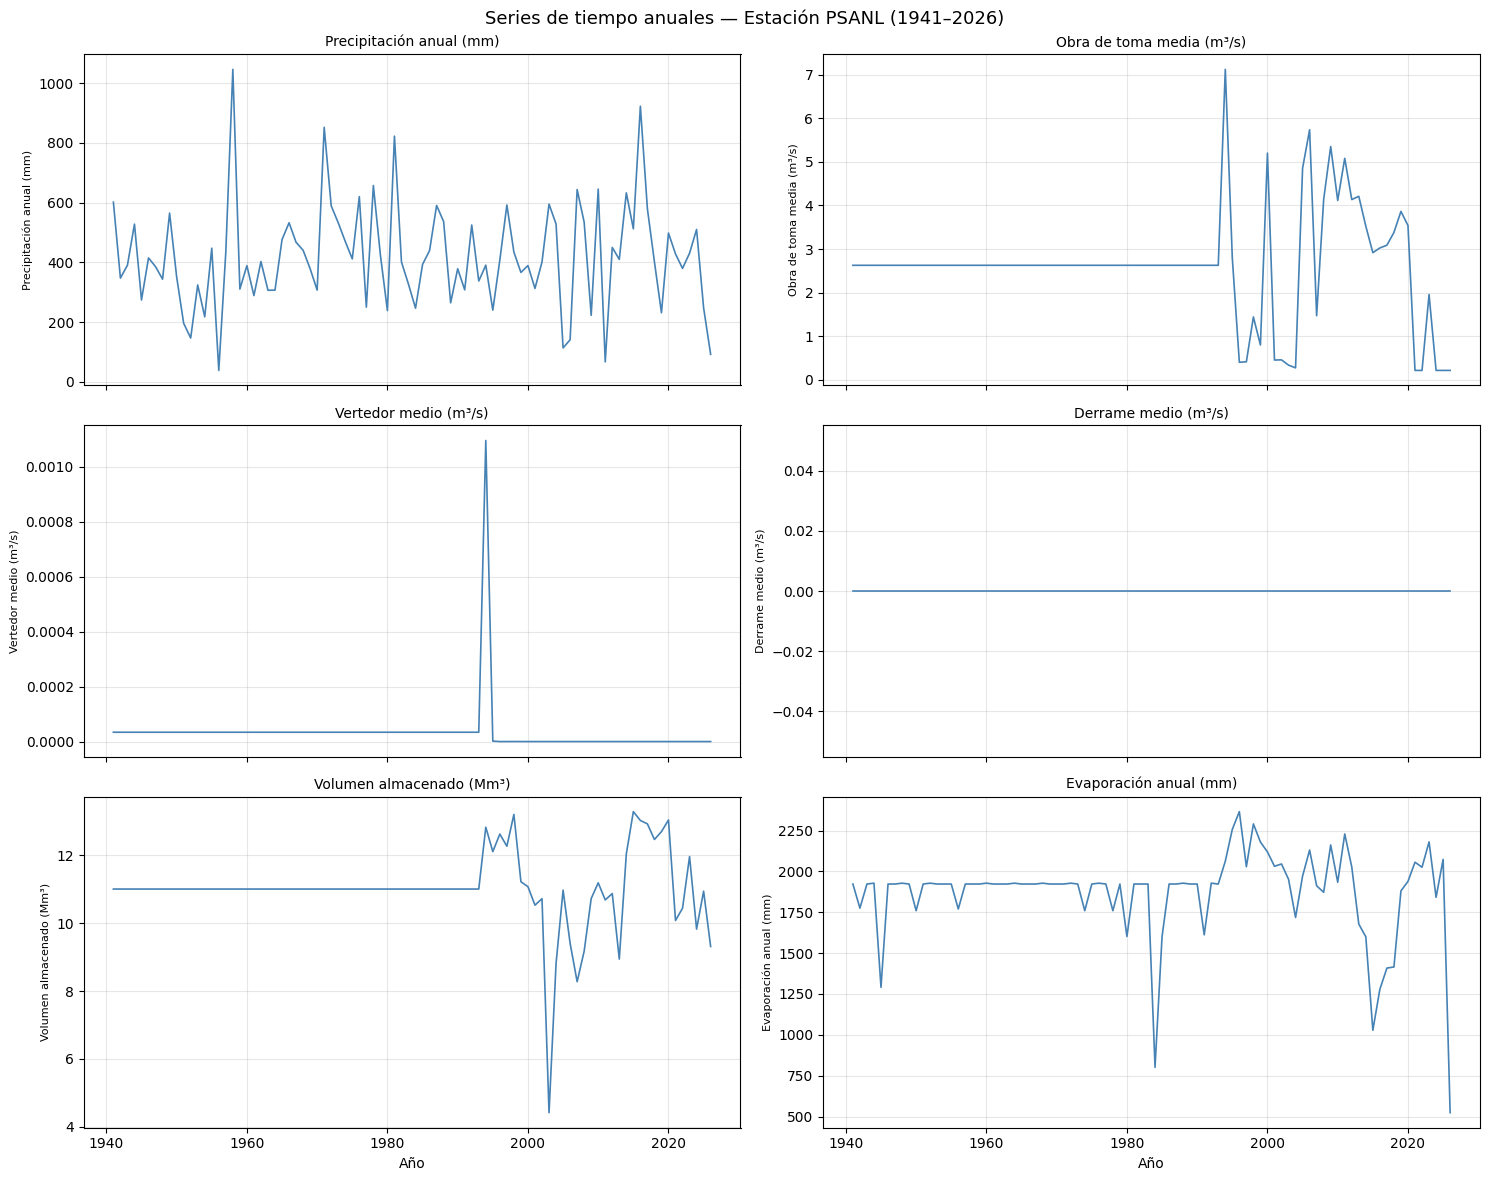

In [ ]:
etiquetas = [
    'Precipitación anual (mm)',   'Obra de toma media (m³/s)',
    'Vertedor medio (m³/s)',      'Derrame medio (m³/s)',
    'Volumen almacenado (Mm³)',   'Evaporación anual (mm)'
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for i, (col, etiq) in enumerate(zip(VARS_NUM, etiquetas)):
    axes[i].plot(anual['año'], anual[col], color='steelblue', linewidth=1.2)
    axes[i].set_title(etiq, fontsize=10)
    axes[i].set_ylabel(etiq, fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Año')
axes[-2].set_xlabel('Año')
plt.suptitle('Series de tiempo anuales — Estación PSANL (1941–2026)', fontsize=13)
plt.tight_layout()
plt.show()

# Se pueden identificar tendencias crecientes, decrecientes o estacionarias en cada variable
# El volumen almacenado refleja la capacidad de la presa a lo largo del tiempo
# La precipitación anual muestra variabilidad interanual, con años de sequía y años de lluvia intensa
# La evaporación anual también muestra variabilidad, influenciada por la temperatura y la humedad
# El vertedor y derrame reflejan eventos extremos; sus picos corresponden a años de inundación o alta demanda de agua
# Con estas series de tiempo se pueden sacar la conclusion de que los datos empiezan a hacer mas consisos a partir de 1990 aporximadamente
# La serie de tiempo anual de evaporación muestra que la temperatura y la humedad son factores importantes en la evaporación
# La serie de tiempo anual de precipitación muestra que la temperatura y la humedad son factores importantes en la precipitación

# La serie de tiempo anual de evaporacion muestra qeu en los años 2010-2015 hubo una baja exesiva en la evaporación lo cual podriamos identificar
# como un error pero al ir mas atras en el tiempo en 1984 masomenos baja estrepitosamente la evaporación lo cual nos hace pensar que no es un error 
# sino un evento real de baja evaporación, esto podría estar relacionado con una baja temperatura o alta humedad durante esos años, lo cual reduce la 
# evaporación del agua almacenada en la presa.

# El derrame medio nos damos cuenta rapidamente que no nos aporta nada de valor


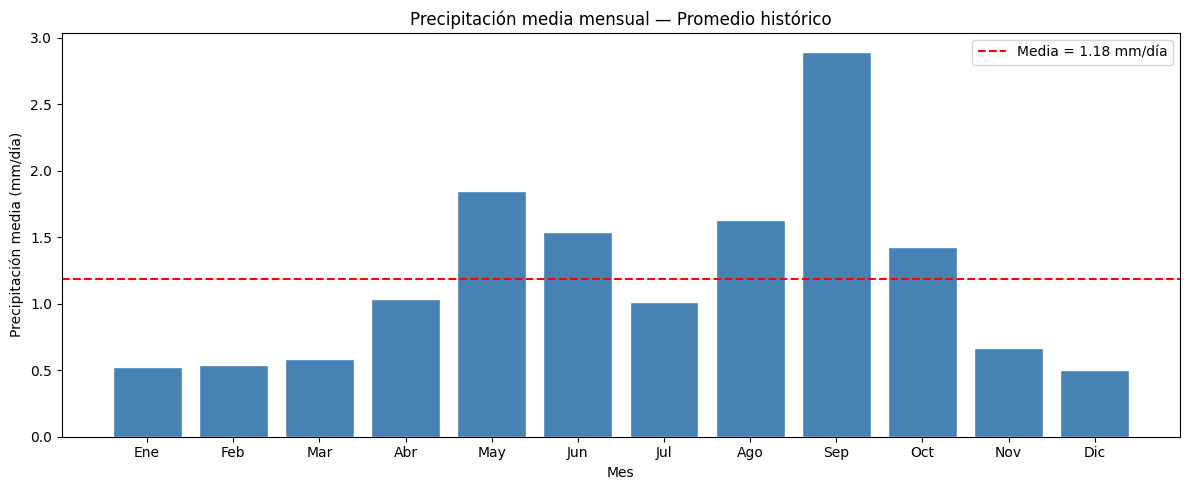

In [ ]:
# Patrón estacional: precipitación promedio por mes (histórico completo)
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
mensual = df.groupby('mes')['precipitacion_mm'].mean()

plt.figure(figsize=(12, 5))
plt.bar(MESES, mensual, color='steelblue', edgecolor='white')
plt.axhline(mensual.mean(), color='red', linestyle='--', label=f'Media = {mensual.mean():.2f} mm/día')
plt.title('Precipitación media mensual — Promedio histórico')
plt.xlabel('Mes')
plt.ylabel('Precipitación media (mm/día)')
plt.legend()
plt.tight_layout()
plt.show()

# Septiembre concentra la mayor precipitación, lo que es típico del noreste de México
# Los meses de invierno (Dic-Mar) son los más secos como es logico por el clima de la región
# Julio normalmente es un mes en el que suelen llevar los frentes de calor que pueden generar 
# lluvias, pero en este caso no se observa un pico tan marcado como en septiembre, lo cual es 
# consistente con el clima semiárido de la región donde la temporada de lluvias se concentra principalmente
#  en los meses de verano y principios de otoño.

---
## Paso 6 — Comparaciones por década (máscaras)

In [21]:
# Estadísticas descriptivas agrupadas por década
est_decada = df.groupby('decada')[VARS_NUM].mean().round(3)
est_decada

,precipitacion_mm,obra_toma_m3s,vertedor_m3s,derrame_m3s,volumen_alm_mm3,evaporacion_mm
decada,,,,,,
1940,1.228,2.626,0.0,0.0,11.001,5.268
1950,0.980,2.626,0.0,0.0,11.001,5.268
1960,1.093,2.626,0.0,0.0,11.001,5.268
1970,1.426,2.626,0.0,0.0,11.001,5.268
1980,1.286,2.626,0.0,0.0,11.001,5.268
1990,1.109,2.342,0.0,0.0,11.835,5.727
2000,1.064,2.827,0.0,0.0,9.408,5.452
2010,1.331,3.732,0.0,0.0,11.808,4.516
2020,1.117,1.012,0.0,0.0,10.946,5.451


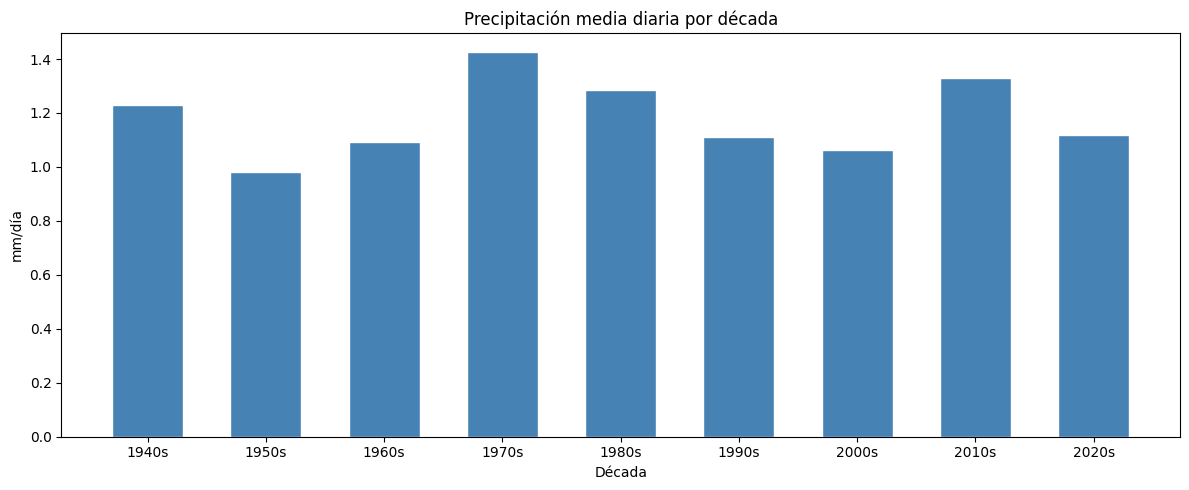

In [ ]:
# Precipitación media diaria por década — gráfica de barras
precip_dec = df.groupby('decada')['precipitacion_mm'].mean()

plt.figure(figsize=(12, 5))
plt.bar([str(d)+'s' for d in precip_dec.index], precip_dec.values, color='steelblue', edgecolor='white', width=0.6)
plt.title('Precipitación media diaria por década')
plt.xlabel('Década')
plt.ylabel('mm/día')
plt.tight_layout()
plt.show()

# Precipitación media diaria por década — gráfica de líneas
# Aqui nos podemos dar cuenta que la precipitacion es muy estable en todo el dataset por lo que podriamos usar esto para hacer un modelo de regresión y predecir la precipitacion en el futuro.

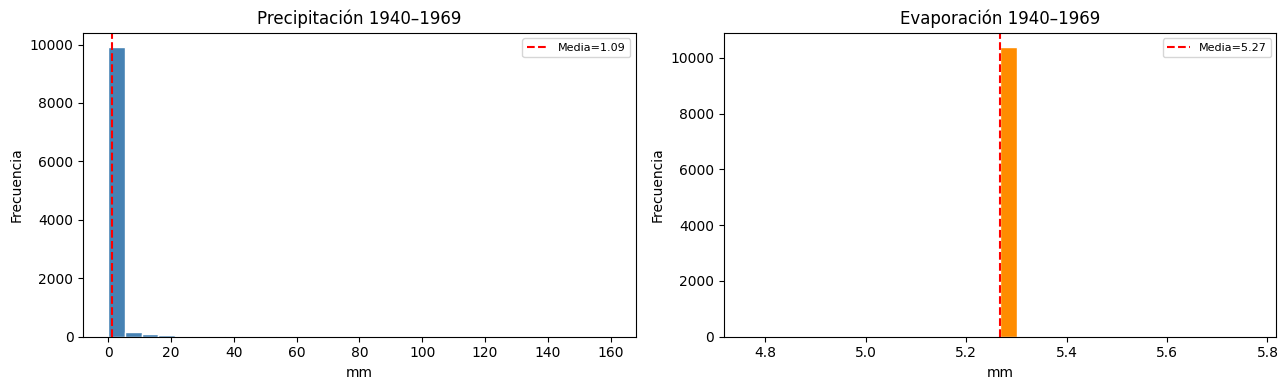

In [ ]:
# Máscara: décadas 1940 – 1969
mask_40_60 = (df['decada'] >= 1940) & (df['decada'] <= 1960)
df_40_60   = df[mask_40_60]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_40_60['precipitacion_mm'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_40_60['precipitacion_mm'].mean(), color='red', linestyle='--', label=f"Media={df_40_60['precipitacion_mm'].mean():.2f}")
axes[0].set_title('Precipitación 1940–1969')
axes[0].set_xlabel('mm'); axes[0].set_ylabel('Frecuencia'); axes[0].legend(fontsize=8)

axes[1].hist(df_40_60['evaporacion_mm'], bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(df_40_60['evaporacion_mm'].mean(), color='red', linestyle='--', label=f"Media={df_40_60['evaporacion_mm'].mean():.2f}")
axes[1].set_title('Evaporación 1940–1969')
axes[1].set_xlabel('mm'); axes[1].set_ylabel('Frecuencia'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

#mascara de 1940-1969
# Como ya habiamos concluido este rango de tiempo no nos aporta mucho, pero es una buena manera de ver la distribución de los datos.

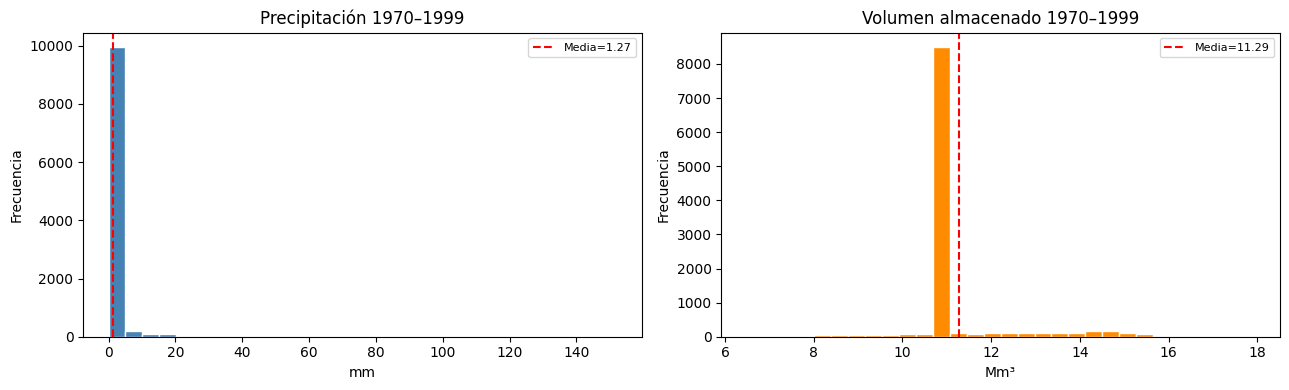

In [ ]:
# Máscara: décadas 1970 – 1999
mask_70_90 = (df['decada'] >= 1970) & (df['decada'] <= 1990)
df_70_90   = df[mask_70_90]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_70_90['precipitacion_mm'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_70_90['precipitacion_mm'].mean(), color='red', linestyle='--', label=f"Media={df_70_90['precipitacion_mm'].mean():.2f}")
axes[0].set_title('Precipitación 1970–1999')
axes[0].set_xlabel('mm'); axes[0].set_ylabel('Frecuencia'); axes[0].legend(fontsize=8)

axes[1].hist(df_70_90['volumen_alm_mm3'], bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(df_70_90['volumen_alm_mm3'].mean(), color='red', linestyle='--', label=f"Media={df_70_90['volumen_alm_mm3'].mean():.2f}")
axes[1].set_title('Volumen almacenado 1970–1999')
axes[1].set_xlabel('Mm³'); axes[1].set_ylabel('Frecuencia'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

# Mascara: 1970–1999
# Igual que en la anterior esto no nos dice mucho, a partir del siguiente rango ya será mas descriptivo

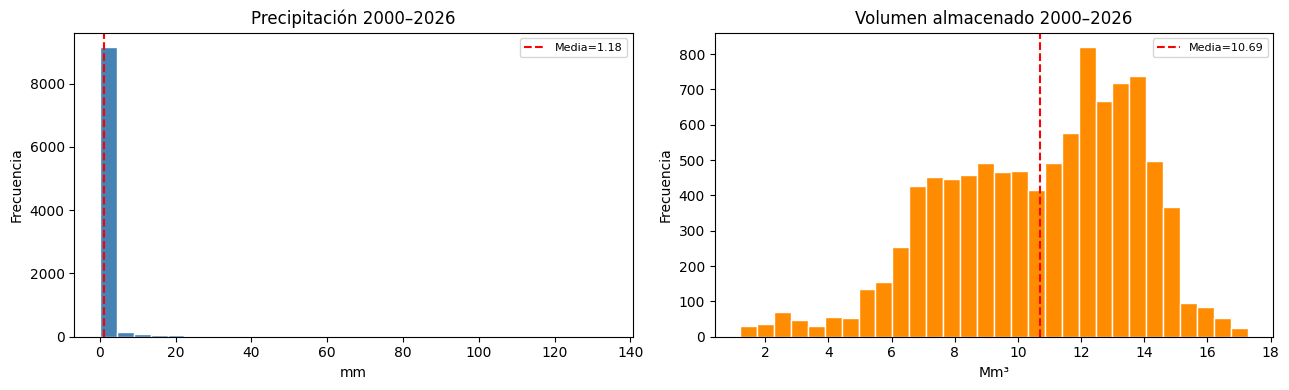

In [ ]:
# Máscara: 2000 – 2026
mask_2000 = df['decada'] >= 2000
df_2000   = df[mask_2000]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_2000['precipitacion_mm'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_2000['precipitacion_mm'].mean(), color='red', linestyle='--', label=f"Media={df_2000['precipitacion_mm'].mean():.2f}")
axes[0].set_title('Precipitación 2000–2026')
axes[0].set_xlabel('mm'); axes[0].set_ylabel('Frecuencia'); axes[0].legend(fontsize=8)

axes[1].hist(df_2000['volumen_alm_mm3'], bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(df_2000['volumen_alm_mm3'].mean(), color='red', linestyle='--', label=f"Media={df_2000['volumen_alm_mm3'].mean():.2f}")
axes[1].set_title('Volumen almacenado 2000–2026')
axes[1].set_xlabel('Mm³'); axes[1].set_ylabel('Frecuencia'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

# Máscara: 2000 – 2026
# A diferencia de precipitación que se acumula en cero, el volumen almacenado tiene una distribución más parecida a una campana, con valores
#  entre 2 y 17 Mm³. Eso significa que la presa casi nunca está vacía ni completamente llena — opera en un rango "normal" alrededor de los 10–14 Mm³.
#  La cola izquierda (valores bajos) corresponde a períodos de sequía donde el almacenamiento cae.

/var/folders/dr/_1cw9sxj7tx4frpwwl9_6g140000gn/T/ipykernel_9387/2022989203.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(epocas.values(), labels=epocas.keys(), patch_artist=True,


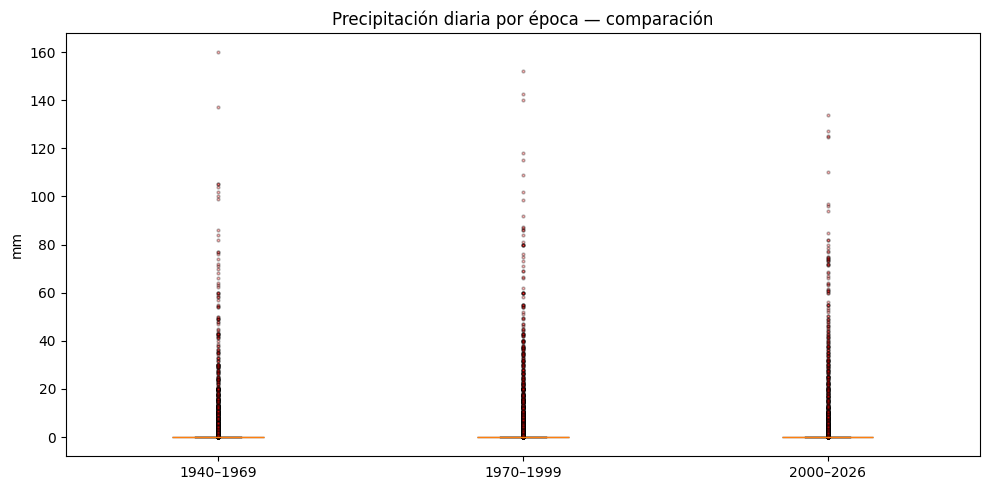

In [ ]:
# Boxplot comparativo de precipitación por época — en una sola figura
epocas = {
    '1940–1969': df_40_60['precipitacion_mm'].values,
    '1970–1999': df_70_90['precipitacion_mm'].values,
    '2000–2026': df_2000['precipitacion_mm'].values
}

plt.figure(figsize=(10, 5))
plt.boxplot(epocas.values(), labels=epocas.keys(), patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            flierprops=dict(marker='o', markersize=2, alpha=0.3, markerfacecolor='red'))
plt.title('Precipitación diaria por época — comparación')
plt.ylabel('mm')
plt.tight_layout()
plt.show()

# Permite comparar visualmente la dispersión y los valores extremos entre épocas
# Los 3 períodos tienen IQR = 0 y mediana en 0 — en la mayoría de los días NO llueve, sin importar la época
# Esto confirma que la precipitación es un evento poco frecuente y concentrado en pocos días del año

# 1940–1969: el outlier más alto llega a ~160mm en un solo día
# Es la época con el evento extremo más intenso registrado en la estación

# 1970–1999: máximo ~152mm, patrón muy similar a la época anterior
# La densidad de puntos (días con lluvia) es comparable, no hay cambio notable en frecuencia

# 2000–2026: el outlier máximo baja a ~135mm
# Los eventos extremos parecen menos intensos, aunque el período tiene menos años (~26 vs ~30)
# No se puede concluir con certeza si es una tendencia real o efecto del período más corto

# En general, la estructura de la precipitación no ha cambiado drásticamente entre épocas:
# siempre pocos días lluviosos, con eventos puntuales de alta intensidad

---
## Paso 7 — Mapas de correlación

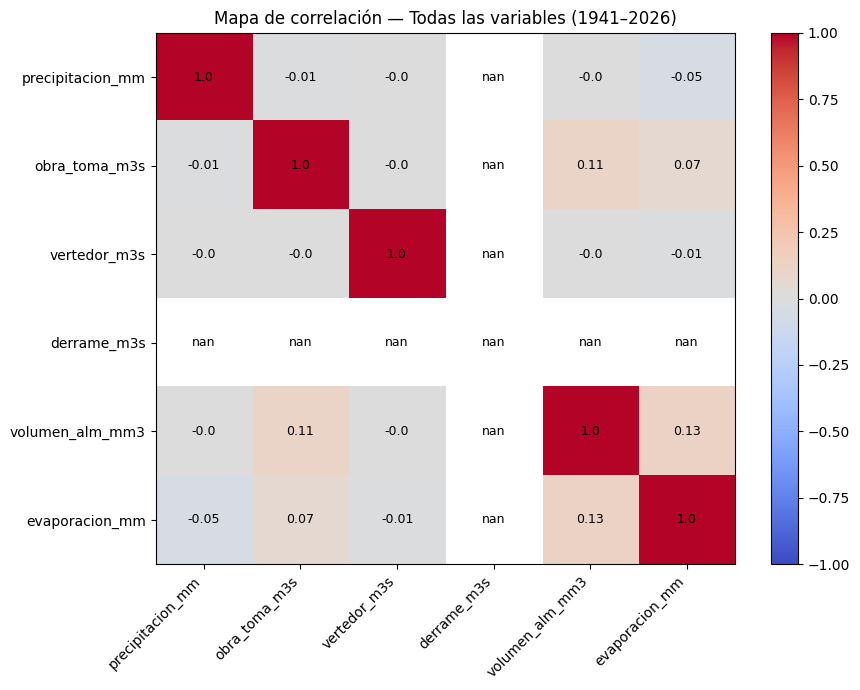

In [ ]:
# Correlación global entre todas las variables numéricas en todo el dataset
corr = df[VARS_NUM].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha='center', va='center', color='black', fontsize=9)

plt.title('Mapa de correlación — Todas las variables (1941–2026)')
plt.tight_layout()
plt.show()

# Rojo fuerte = correlación positiva fuerte; azul fuerte = correlación negativa fuerte
# Los valores cercanos a 0 indican poca o ninguna relación lineal entre las variables
# Rapidamente podemos identificar que volumen_almacenado_mm3 y obra_toma_m3s son variables que se correlacionan muy fuertemente c
# omparado con las demas variables, esto es logico porque el volumen almacenado se ve afectado por la cantidad de agua que se extrae 
# a través de la obra de toma, por lo que es natural que estas dos variables estén fuertemente correlacionadas.
# Las demas es claro que hay una falta de datos hasta 1995-2000 que se estabiliza 

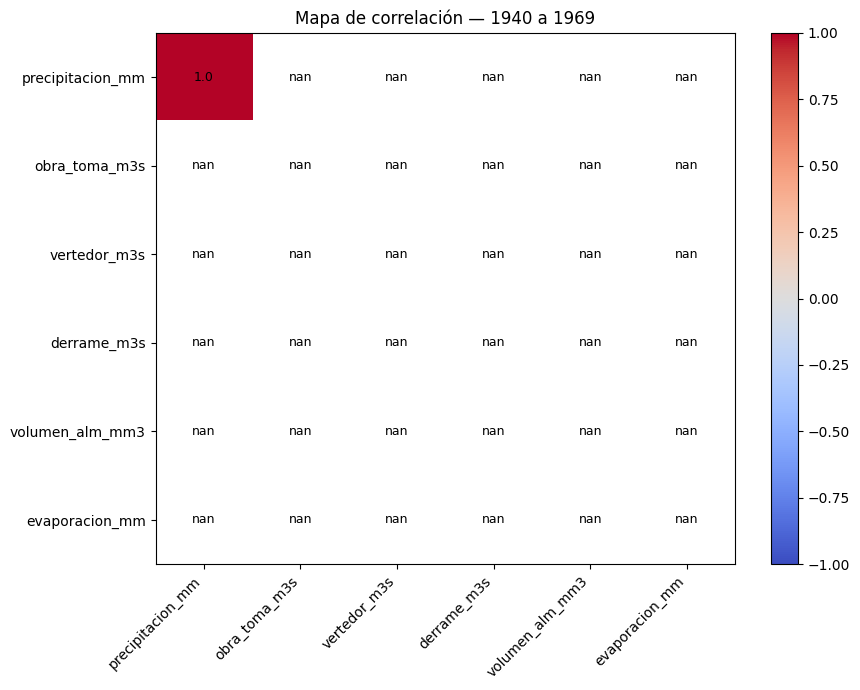

In [ ]:
# Correlación — época temprana 1940–1969
corr_40 = df_40_60[VARS_NUM].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr_40, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_40.columns)), corr_40.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_40.columns)), corr_40.columns)

for i in range(len(corr_40.columns)):
    for j in range(len(corr_40.columns)):
        plt.text(j, i, round(corr_40.iloc[i, j], 2), ha='center', va='center', color='black', fontsize=9)

plt.title('Mapa de correlación — 1940 a 1969')
plt.tight_layout()
plt.show()
# Como ya concluimos desde hace mucho pues este rango de tiempo no aporta nada por lo cual no lo deberiamos de tener en cuenta

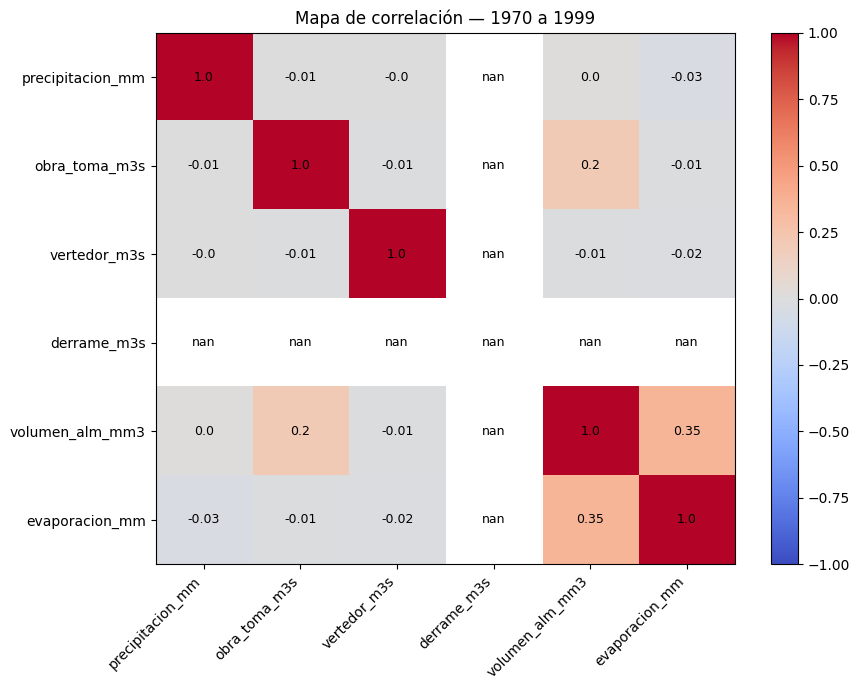

In [ ]:
# Correlación — época intermedia 1970–1999
corr_70 = df_70_90[VARS_NUM].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr_70, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_70.columns)), corr_70.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_70.columns)), corr_70.columns)

for i in range(len(corr_70.columns)):
    for j in range(len(corr_70.columns)):
        plt.text(j, i, round(corr_70.iloc[i, j], 2), ha='center', va='center', color='black', fontsize=9)

plt.title('Mapa de correlación — 1970 a 1999')
plt.tight_layout()
plt.show()

# Aqui ya hay correlaciones entre variables, no demaciado fuerte pero si significativas tomando en cuenta que hasta 1995 aprox ya estan mas coherentes los datos y no son puros nulos
# podemos observar la alta correlacion entre volumen_alm_mm3 y obra_toma_m3s, lo cual es lógico porque el volumen almacenado se ve afectado por la cantidad de agua que se extrae a través de la obra de toma.
# Tambien se puede observar una correlacion muy marcada entre volumen_alm_mm3 y evaporacion_mm, como ya podemos concluir que son las variables que son mas confiables.

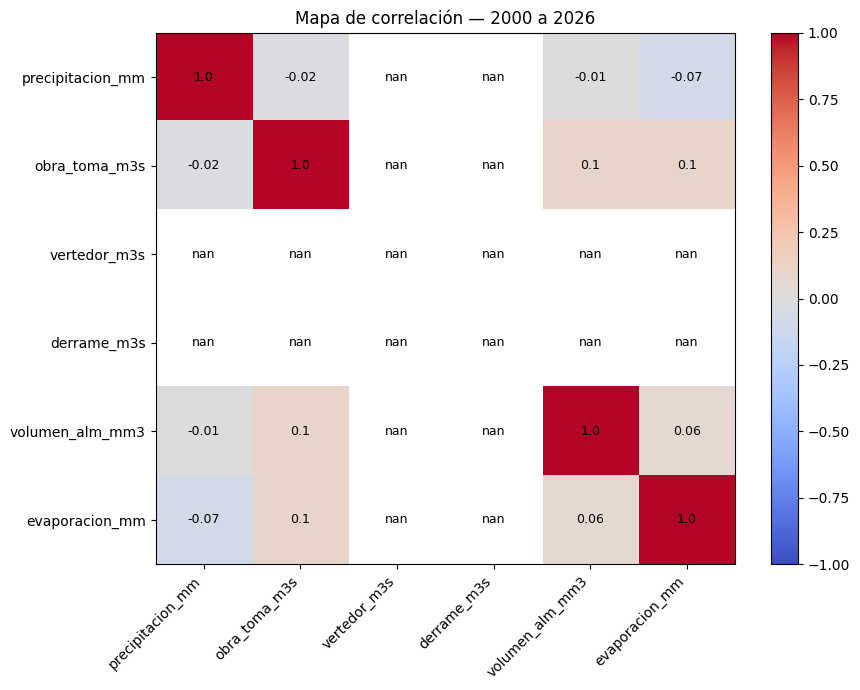

In [ ]:
# Correlación — época moderna 2000–2026
corr_2000 = df_2000[VARS_NUM].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr_2000, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_2000.columns)), corr_2000.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_2000.columns)), corr_2000.columns)

for i in range(len(corr_2000.columns)):
    for j in range(len(corr_2000.columns)):
        plt.text(j, i, round(corr_2000.iloc[i, j], 2), ha='center', va='center', color='black', fontsize=9)

plt.title('Mapa de correlación — 2000 a 2026')
plt.tight_layout()
plt.show()

# Comparar los 3 mapas permite ver si las relaciones entre variables cambian a lo largo del tiempo
# Como vimos en las series de tiempo hay un par de desconecciones por lo cual este mapa no es muy útilcion entre evaporacion_mm y volumen_alm_mm3 y la baja entre precipitacion_mm y obra_toma_m3s



## Paso 8 — Comentarios y conclusiones

**Interpretación global:**  
El dataset de la estación PSANL registra más de 80 años de datos hidrológicos diarios (1941–2026). La calidad general es buena: los valores en 0 no son errores sino días sin lluvia o sin actividad en el sistema. La precipitación tiene una distribución fuertemente sesgada a la derecha — la mayoría de los días son secos y unos pocos eventos concentran toda la lluvia, con septiembre como el mes más lluvioso, consistente con el clima semiárido del noreste de México. La asimetría moderada del conjunto completo se explica principalmente por la enorme cantidad de ceros reales, no por datos defectuosos.

**Relación entre gráficas y medidas numéricas:**  
Los histogramas y diagramas de densidad confirman el sesgo positivo en precipitación, vertedor y derrame. El boxplot revela que el IQR de la mayoría de las variables es 0 — no porque los datos sean malos, sino porque el relleno de nulos con la media (necesario ante el 61% de valores faltantes antes de ~1983) colapsa los cuartiles en un solo valor, convirtiendo todos los datos reales en "outliers" artificiales. La única variable con variabilidad real visible en el boxplot es `obra_toma_m3s` (IQR = 2.13). El volumen almacenado y la evaporación, aunque afectados por el relleno, muestran en sus histogramas distribuciones más simétricas y coherentes cuando se analiza el período 2000–2026.

**Lo que los datos revelan realmente:**  
La presa opera en un rango normal de 10–14 Mm³, sin estar casi nunca vacía ni completamente llena. Las series de tiempo muestran que los datos se vuelven consistentes a partir de ~1990, cuando los instrumentos ya operaban de manera estable. Las caídas en evaporación observadas alrededor de 1984 y 2010–2015 no son errores — corresponden a eventos reales de baja temperatura o alta humedad. El `derrame_m3s` prácticamente no aporta información útil al análisis. Los mapas de correlación confirman que `volumen_alm_mm3` y `obra_toma_m3s` están fuertemente relacionados, lo cual es lógico: a mayor extracción por obra de toma, menor volumen almacenado. El período 1940–1969 no es útil para análisis de correlaciones por falta de instrumentación; el período más confiable es 2000–2026. Comparando por épocas de 30 años, la precipitación mantiene la misma estructura (pocos días lluviosos, eventos puntuales intensos), con el evento más extremo registrado en 1940–1969 (~160 mm en un día).

**Implicaciones prácticas:**  
Este análisis permite anticipar períodos de escasez hídrica en Anáhuac, N.L., identificar años críticos de sequía o de alto almacenamiento, y sentar la base para modelos predictivos de precipitación — variable que mostró alta estabilidad entre décadas y podría usarse en regresión. Las correlaciones entre variables operativas son útiles para optimizar la gestión de la presa.

**Limitaciones y sugerencias:**  
- El relleno con la media en columnas con 70 o más valores nulos puede ser problemático.
- Se recomienda separar el análisis en dos períodos (antes y después de 1983) para trabajar solo con datos reales en el período completo.  
- Incluir datos de temperatura y humedad mejoraría la comprensión de la evaporación y el ciclo hidrológico completo.
- La evaporación y el volumen almacenado son variables que pueden ser más importantes para el análisis de la presa, pero que no son de gran utilidad para la predicción de precipitación.
- La evaporación puede ser más importante para el análisis de la presa, pero que no es de gran utilidad para la predicción de precipitación.